<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>TIME SERIES </h2>
</div>

- Time Series based on time some future predictions or data pattern can be determined
- Time series can be defined as a "set of data dependent on time"
- Time acts as independent variable to estimate dependent variable.
- Mathematically, a time series is as set of observation taken at a specified times(Usually at equal intervals)
- TSA can be done only if i/p variables are stationary.
- ARIMA Model (Auto Regressive Integrated Moving Average) used to predict TS data



#### Components in TSA		
######  1. Trend	

> Growth or a decline in Time series over a long period
        
######  2. Seasonality	

> Based on the season repeating pattern within a fixed time frame within a year.
        
######  3. Cyclic patterns	

> Repeating up and down movement.
        
###### 4. Irregular	

> Certain changes occuring in period, which unlikely to be repeating.(which are no repeating pattern)

> Irregularity occurs due to white noise



#### Different TS models:	

###### 1. AR Model(Auto Regressive Model)	

> It’s a TS model, values of a variable in one period is related to its values in previous period.

> Here it depends on current i/p and previous timeseries output( which is Lag value)

> But in simple linear regresssion o/p (y(t)  it depended only current input X(t), its not dependnt on previous o/p y(t-1). only in Auto Regression this model y(t) dependent on previous o/p y(t-1)

######  2. Moving average Model (MA Model)		

> Here it depends current i/p and on previous timeseries error values not on o/p value	


######  3. ARMA Model (ARIMA Model - AutoRegressive Integrated Moving Average)			

> It combines both AR and MA model and provides better predictions	

> In this both models formula will be combined.		

> ARMA model is valid only if i/p variables are stationary.		


        
##### By using this model we can see the predicted forcasted o/p	

- 1. Read the data, if data having date col and any other col, then we can assume it as timeseries data		


- 2. Convert Date col as index and change datatype to date format and draw the plot on value, so automatically graph will treat x axis as dates and values as y axis		


- 3. If data is too many and its overlapping, then we can do resampling mean based on week etc. this is feature 'resample' with mean in python for timeseries type data	


- 4. Before applying ARIMA model we need to check stationarity of data, mean should be constant.  1 way -->  by plotting mean data after applying rolling mean. 2 way -->  by Dickey Fuller test		


- 5. Write function to do below 2 tests and plot the graph and dickey puller details, based on this result we decide stationarity of data		

> 1. In python we have 'rolling' function to see mean and std, then plot this data and original data, by graph we can see its staionarity	
> 2. Apply Dickey Fuller test (adfuller) and compare 'test_statistic' < critical value 5% and p value<0.05	

- 6. If data in not stationary, then apply 'Detrending' or 'Deferencing' to make it stationary data.		
- 7. Then pass this new data in above stationarity check function and see the conditions. If all matches and data is stationary we will apply ARIMA model	

- 8. To apply ARIMA, we need p logs and q logs, for that we use 'acf and 'pacf' models	

> 1	where it crosses upper confidence level in graph,that x axis value  will becomes q values log. In graph x is log value(X=1) and y is q value.  So q value= 1(xvalue)
> 2	where it crosses 0 confidence level in graph, that x axis value will becomes p values log. In graph x is log value and y is p value. So p value= 2(xvalue)

- 9.Apply Arima model, Plot the ARIMA model, RSS, summary and residual error plot,we will draw residual plot, if plots peak is centered at 0 then model is good. but here Predictions, but its not in original scale	


- 10. Here data wont be original state, we need to do scaling to convert back to Original set, so that gaves prediction back in original. (Cum-->Diff-->Exp etc)		


- 11. Split the data to test and train. Use Training data to train the ARIMA model and perform out-of-sample forcasting.		


- 12.After applying ARMAmodel fit,prdict etc, Then you will compare the results of your out-of-sample predictions for EURO rate with the actual values from the test data	


- 13. Validating the model: Validating the model by comparing out-of-sample predictions for Euro rate with actual values from the test dataset and calculating the mean squared error


- 14. Then Plotting forecasting v/s observed value
		


<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## Module 13, Time SERIES

### Case Study

#### Domain –SEA Transportation

#### focus –forecast demand

#### Business challenge/requirement
- SeaPort is the largest operator of Sea Planes across sea shores in Europe.  
- SeaPort doesn't have planes of their own, rather they lease them on a short term basis based on passenger traffic.
- You as an ML expert have to build a model to forecast the demand (passenger traffic) of traffic. 

#### Key issues
- As of now utilization of Planes is low due to poor forecastsof traffic

#### Considerations 
- NONE

#### Data volume
- -Approx 144 records–data month wise for last 12 years –file SeaPlaneTravel.csv 
* Fields in Data
     • Month: Month in which traffic data was recorded 
     •'#Passenger': No of travellers availing Service in that month
        
#### Additional information-NA

#### Business benefits
- Better utilization of planes will lead to decrease in cost and hence better bottom line


##  1. Import all Librariy

In [26]:
import requests, pandas as pd, numpy as np
from pandas import DataFrame
import time, json
from datetime import date

# To check stationarity and find p and q value
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima_model import ARIMA

from sklearn.metrics import mean_squared_error


import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = [15, 6]

In [27]:
#Here it converts 1st col='month' to index value and converts index'Month' to date datatype
df_fx_data = pd.read_csv(r'..\Dataset\SeaPlaneTravel.csv'
                         ,index_col='Month',parse_dates=['Month'])

#dateparse = lambda dates: pd.datetime.strptime(dates, '%Y-%m')

indexed_df = df_fx_data

df_fx_data.head()

,#Passengers
Month,
2003-01-01,112
2003-02-01,118
2003-03-01,132
2003-04-01,129
2003-05-01,121


In [28]:
#Convert date col to data type date, before it was object, not sure how to do in case YYYY-MM  format

#Change date col from col to index in df
#Change index 0,1,2, to date col
#indexed_df = df_fx_data.set_index('Month')
#sample value considered, plot was not displyed properly
#indexed_df = indexed_df[:40]

print(indexed_df.head())
#print(df_fx_data['Month'].head())

            #Passengers
Month                  
2003-01-01          112
2003-02-01          118
2003-03-01          132
2003-04-01          129
2003-05-01          121


## 2. Data Exploration

** More Inspections

In [29]:
# print (df.index)
#print (df.describe())
#print ("=============================================================")
#print (df.dtypes)

(array([730851., 731581., 732312., 733042., 733773., 734503., 735234.,
        735964.]), <a list of 8 Text xticklabel objects>)

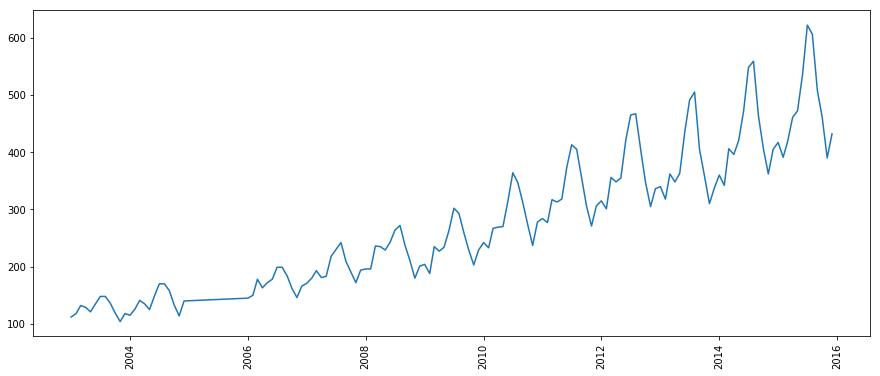

In [30]:
#Visulaize the time series data

ts = indexed_df['#Passengers']
#ts.head(5)
plt.plot(ts)
plt.yticks(rotation=0)
plt.xticks(rotation=90)


## 3. STATIONARTY DATA CHECK

### 3.1 Stationarity Check : 
> 1) Rolling Statistic

> 2) Dickey Fuller Test

##### 3.1.1 Created funct to check both Rolling statistic and Dickey Fuller test

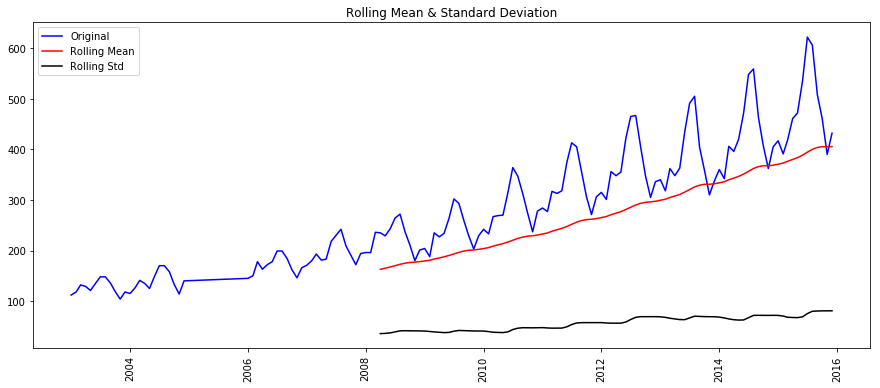

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [31]:
#Test stationarity by 1) plotting rolling mean and rolling std graph 2) Dickey puller test

def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=52,center=False).mean() 
    rolstd = timeseries.rolling(window=52,center=False).std()
    
    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)
    plt.show(block=False)
       
    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    
    #here dftest will have tuple like below with 4 values and 1 dictionary, another value
    """(-2.076340599933076, 
    0.2541339550926388, 
    2, 
    2234, 
    {'1%': -3.4332805415364724, '5%': -2.8628346299364282, '10%': -2.5674591931002038},
    -14013.954809290073)
    """
   
    #Here 1st 4 values are converted to series with giving index name
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

    # Here 5th value is a dictionary, is converted to each row and appended to  dfoutput
    for key,value in dftest[4].items():
        #Here appends rows "Critical Value (%s)" to dfoutput
        dfoutput['Critical Value (%s)'%key] = value
    
    #print dfout
    print(dfoutput)
test_stationarity(ts)

### 3.2  Conclusion: 

##### Rolling Statistic

- Here red line - Rolling Mean  is not constant, its fluctuating, so Time series data in not statistic. Only Rolling std is little contant

##### Dicky puller test

- "Test statistic" is less than the 5%critical value. ----> 0.815369  < -2.862835    ---> False

- p-value LESS than 0.05. ----> 0.991880 < 0.05   ---> False

- Both are false, so its Null hypothesis cant be rejected, so its not stationary Time series data

## 4. CONVERT DATA TO STATIONARTY DATA 

### 4.1 To make Stationarity, Can Apply 1) Detrending or 2) Differencing

>  If data in not stationary, then apply 'Detrending' or 'Deferencing' to make it stationary data.

> Here Deferencing is applied, which is log and difference of shift it taken

> Data will be applied with log transformation prior to differencing for better result. Only with log it wont convert data to stationary

> To make stationary some time we need to take log, some time, square, some time cube

TS with log :
  Month
2003-01-01    4.718499
2003-02-01    4.770685
2003-03-01    4.882802
2003-04-01    4.859812
2003-05-01    4.795791
Name: #Passengers, dtype: float64

 TS with log and shifted :
  Month
2003-01-01         NaN
2003-02-01    4.718499
2003-03-01    4.770685
2003-04-01    4.882802
2003-05-01    4.859812
Name: #Passengers, dtype: float64

 TS log after Difference :
  Month
2003-01-01         NaN
2003-02-01    0.052186
2003-03-01    0.112117
2003-04-01   -0.022990
2003-05-01   -0.064022
Name: #Passengers, dtype: float64


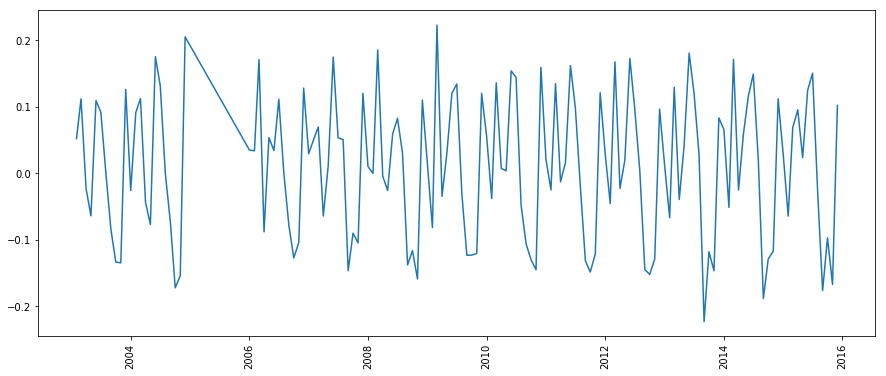

In [32]:
# lOG APPLIED 1st

ts_week_log = np.log(ts)
#Shift function of pandas.Dataframe shifts index by desired number of periods with an optional time freq.
# here default 1 index position shifted
ts_week_log_diff = ts_week_log - ts_week_log.shift()
plt.plot(ts_week_log_diff)
plt.yticks(rotation=0)
plt.xticks(rotation=90)


print("TS with log :\n " ,ts_week_log.head())
print("\n TS with log and shifted :\n " , ts_week_log.shift().head())
print("\n TS log after Difference :\n " ,ts_week_log_diff.head())

### 4.1.1 Remove any null value and check stationarity after differencing

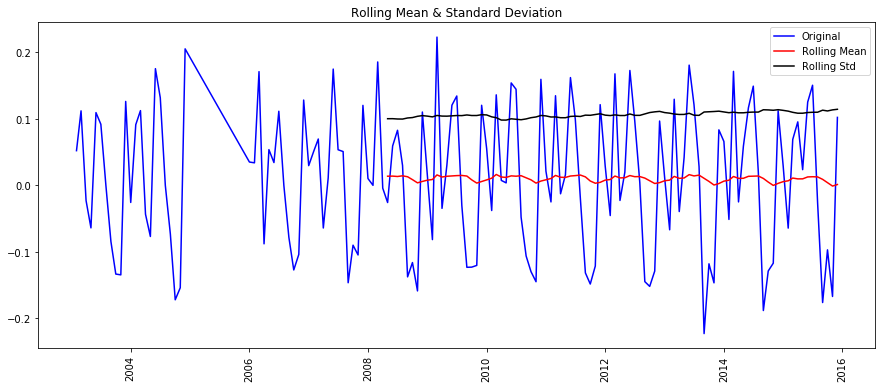

Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [33]:
#Remove any null value and check stationarity after differencing
ts_week_log_diff.dropna(inplace=True)

# Call the stationarity checking function
test_stationarity(ts_week_log_diff)

### 4.2  Conclusion: 

##### Rolling Statistic
- Here red line - Rolling mean and Green - Rolling std is constant, its not much fluctuating, so Time series data is statistic, we can apply ARIMA model now

#####  Dicky puller test

- "Test statistic" is less than the 5%critical value.    ---->   -5.407402 <  -2.862834    ---> True

- p-value lesser than 0.05.    ---->  0.000000 < 0.05   ---> True

#####  Both are True, so its Null hypothesis can be rejected, so its a stationary Time series data



## 5. Calculate Lags/order values by ACF PACF

#### ACF and PACF
> To apply ARIMA, we need p logs and q logs, for that we use 'acf and 'pacf' models

> where it crosses upper confidence level in graph,that x axis value  will becomes q values log. 



In [34]:
#ACF and PACF
#To apply ARIMA, we need p logs and q logs, for that we use 'acf and 'pacf' models
lag_acf = acf(ts_week_log_diff, nlags=10)
lag_pacf = pacf(ts_week_log_diff, nlags=10, method='ols')

### 5.1 Plot ACF

Text(0.5, 1.0, 'Autocorrelation Function')

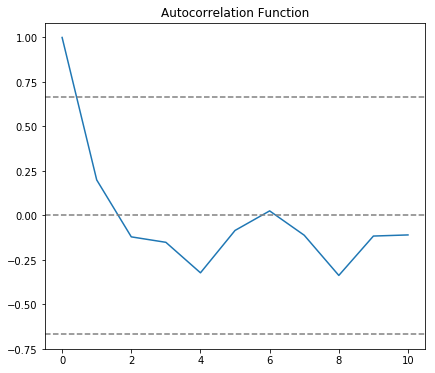

In [35]:
#Plot ACF: 
#where it crosses upper confidence level in graph,that x axis value  will becomes q values log. 

plt.subplot(121) 
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')

#### 5.1.1  ACF q Value

> It crosses upper confidence level 0.7 in graph,that x axis value  will becomes q values log. Here its 1

>  So q value= 1(xvalue)


### 5.2 Plot PACF

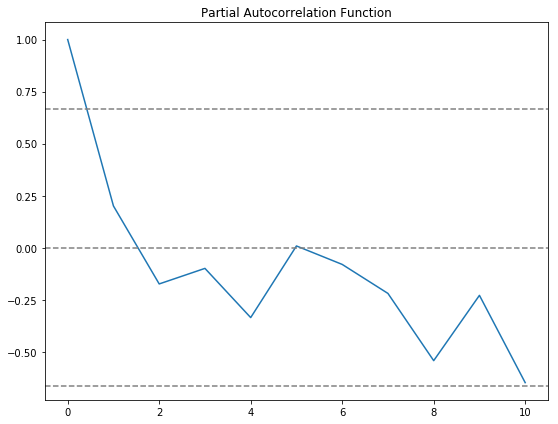

In [37]:
#Plot PACF:
# where it crosses 0 confidence level in graph,that x axis value  will becomes p values log. 

plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.axhline(y=7.96/np.sqrt(len(ts_week_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

#### 5.2.1  PACF p Value

> It crosses 0 confidence level in graph,that x axis value  will becomes p values log. Here its 2

>  So p value= 2(xvalue)

## 6. APPLY ARIMA MODEL

### 6.1 ARIMA model

> Here apply both AR and MA model together means ARIMA with MA's q=1 and AR's p=2 and check RSS

-  Plot original and ARIMA prdicted fitted value and find RSS for this(RSS should be less)

#### RSS - Residual sum of square, greater RSS then bad for us, smaller RSS is good, this will change based on p,q,d value


### Forecast Time Series

- Lets Use the ARIMA model <br>
- ** Q4. What is the RSS error value for ARIMA model after transformation?**

C:\Users\prabh\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:225: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:225: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


Text(0.5, 1.0, 'RSS: 1.0292')

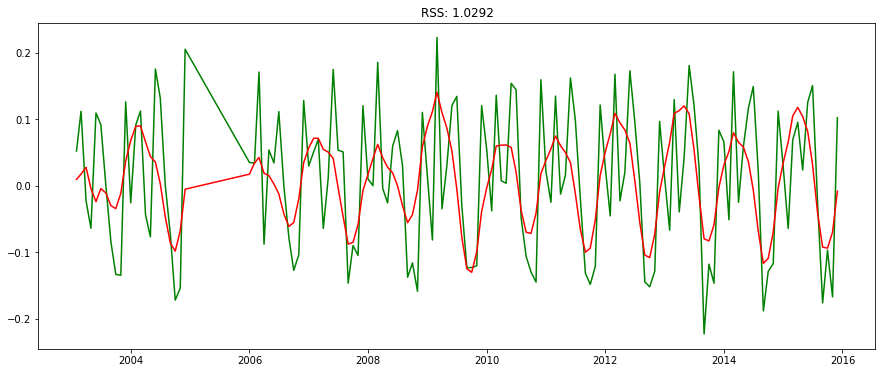

In [38]:
#Apply Arima model

#Above acf and pacf gave p=2,q=1. (p,d,q) =(2,1,1)
#As per EDU p,d,q) =(2,1,2), so we used same here
model = ARIMA(ts_week_log, order=(2, 1, 2))  
#Fit the model 
results_ARIMA = model.fit(disp=-1)  
# Plot the ARIMA model
plt.plot(ts_week_log_diff, color='green')
plt.plot(results_ARIMA.fittedvalues, color='red')
plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-ts_week_log_diff)**2))

### 6.2 ARIMA RSS CONCLUSION


> With Both ARIMA RSS=1.02

### 6.2 ARIMA MODEL SUMMARY - results_ARIMA.summary

> This summarizes the coefficient values used as well as the skill of the fit on the on the in-sample observations.


In [131]:
#Print the ARIMA model summary
#This summarizes the coefficient values used as well as the skill of the fit on the on the in-sample observations.
print(results_ARIMA.summary())

                             ARIMA Model Results                              
Dep. Variable:          D.#Passengers   No. Observations:                  143
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 149.640
Method:                       css-mle   S.D. of innovations              0.084
Date:                Mon, 11 Mar 2019   AIC                           -287.281
Time:                        16:24:45   BIC                           -269.504
Sample:                             1   HQIC                          -280.057
                                                                              
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0096      0.003      3.697      0.000       0.005       0.015
ar.L1.D.#Passengers     1.6293      0.039     41.868      0.000       1.553       1.706
ar.L2.D.#Passeng

### 6.3 ARIMA RESIDUAL ERROR - results_ARIMA.resid

> A residual plot centred around 0 indicates good model(normal distributed with mean centered at 0)

                0
count  143.000000
mean     0.001691
std      0.085116
min     -0.193387
25%     -0.063327
50%     -0.005020
75%      0.074606
max      0.210671


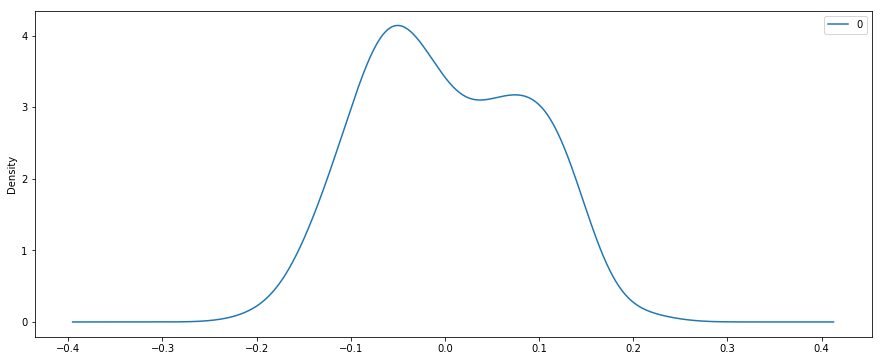

In [39]:
# plot residual errors
residuals = DataFrame(results_ARIMA.resid)
residuals.plot(kind='kde')
print(residuals.describe())
# A residual plot centred around 0 indicates good model

### 6.4 ARIMA PREDICTION - results_ARIMA.fittedvalues

> Here fittedvalues are called as Predictions result, but its not actual scale result

### Getting the data back to original scale

In [40]:
#Predictions, but its not in original scale
predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
print (predictions_ARIMA_diff.head())

Month
2003-02-01    0.009580
2003-03-01    0.017491
2003-04-01    0.027670
2003-05-01   -0.004521
2003-06-01   -0.023890
dtype: float64


## 7. Scaling Predictions:

### Rolling Forecast ARIMA Model

- Now that the model is returning the results you want to see, you can scale the model predictions back to original scale.
- Hence remove the first order differencing and take exponent to restore the predictions back to their original scale.

##### 3steps imp for scaling back transformation
> 1. Cummulative sum

> 2. Prediction

> 3. take exponent


In [42]:

#1. Cummulative rolling sum on prediction
predictions_ARIMA_diff_cumsum = predictions_ARIMA_diff.cumsum()
print("\n predictions_ARIMA_diff_cumsum: \n" ,predictions_ARIMA_diff_cumsum.head())


 predictions_ARIMA_diff_cumsum: 
 Month
2003-02-01    0.009580
2003-03-01    0.027071
2003-04-01    0.054742
2003-05-01    0.050221
2003-06-01    0.026331
dtype: float64


In [43]:
#Original data
predictions_ARIMA_log = pd.Series(ts_week_log.ix[0], index=ts_week_log.index)
print("\n predictions_ARIMA_log: \n" , predictions_ARIMA_log.head())


 predictions_ARIMA_log: 
 Month
2003-01-01    4.718499
2003-02-01    4.718499
2003-03-01    4.718499
2003-04-01    4.718499
2003-05-01    4.718499
dtype: float64


C:\Users\prabh\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: 
.ix is deprecated. Please use
.loc for label based indexing or
.iloc for positional indexing

See the documentation here:
http://pandas.pydata.org/pandas-docs/stable/indexing.html#ix-indexer-is-deprecated
  


In [44]:
#remove the first order differencing 
#2. Prediction sum : it adds predictions_ARIMA_log and predictions_ARIMA_diff_cumsum

predictions_ARIMA_log = predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
print("\n predictions_ARIMA_log after sum: \n" ,predictions_ARIMA_log.head())


 predictions_ARIMA_log after sum: 
 Month
2003-01-01    4.718499
2003-02-01    4.728079
2003-03-01    4.745570
2003-04-01    4.773241
2003-05-01    4.768720
dtype: float64


>  Q5. What is the RSS error value for ARIMA model at original scale? **


 predictions_ARIMA after exponent: 
 Month
2003-01-01    112.000000
2003-02-01    113.078122
2003-03-01    115.073415
2003-04-01    118.301990
2003-05-01    117.768366
dtype: float64


Text(0.5, 1.0, 'RMSE: 90.1045')

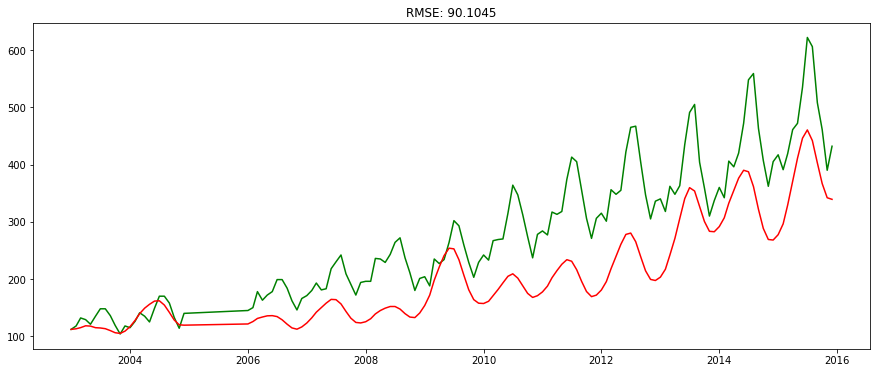

In [45]:
# take exponent, so it will comes back to origial value
#3. take exponent
predictions_ARIMA = np.exp(predictions_ARIMA_log)
print("\n predictions_ARIMA after exponent: \n" ,predictions_ARIMA.head())


plt.plot(ts, color='green')
plt.plot(predictions_ARIMA,color='red')
plt.title('RMSE: %.4f'% np.sqrt(sum((predictions_ARIMA-ts)**2)/len(ts)))

* This a forecast at the original scale

### 8.1 APPLY EARLIER ARIMA MODEL WITH SAME p,q,d

> Use Training data to train the ARIMA model and perform out-of-sample forcasting.

> Then you will compare the results of your out-of-sample predictions for EURO rate with the actual values from the test data

In [46]:
#Split the data to test and train
size = int(len(ts_week_log) - 15)
train, test = ts_week_log[0:size], ts_week_log[size:len(ts_week_log)]
print(train.head())
#Here it converts train data euro value to list
history = [x for x in train]
predictions = list()
print(history[0:10])


Month
2003-01-01    4.718499
2003-02-01    4.770685
2003-03-01    4.882802
2003-04-01    4.859812
2003-05-01    4.795791
Name: #Passengers, dtype: float64
[4.718498871295094, 4.770684624465665, 4.882801922586371, 4.859812404361672, 4.795790545596741, 4.90527477843843, 4.997212273764115, 4.997212273764115, 4.912654885736052, 4.77912349311153]


### 8.2 Use Training data to train the ARIMA model and perform out-of-sample forcasting.
Then you will compare the results of your out-of-sample predictions for EURO rate with the actual values from the test data

In [47]:

print('Printing Predicted vs Expected Values...')
print('\n')
#Loop no of time of test size
for t in range(len(test)):
    #Train model with train data which converted as list
    model = ARIMA(history, order=(2,1,1))
    #Fit model
    model_fit = model.fit(disp=0)
    #forcast, something like predict
    output = model_fit.forecast()
    #print(output)
    #print(yhat)
    
    #output had 4 value, in that 1st value considered
    yhat = output[0]
    predictions.append(float(yhat))
    
    #Actual test data
    obs = test[t]
    #Not clear
    history.append(obs)
print('predicted=%f, expected=%f' % (np.exp(yhat), np.exp(obs)))

Printing Predicted vs Expected Values...


predicted=411.460155, expected=432.000000


## 9 ARIMA model Validation

- Validating the model by comparing out-of-sample predictions for Euro rate with actual values from the test dataset and calculating the mean  squared error

### 9.1 ARIMA model Validation - MSE

In [48]:
#Validating the model
error = mean_squared_error(test, predictions)
print('\n')
print('Printing Mean Squared Error of Predictions...')
print('Test MSE: %.6f' % error)
predictions_series = pd.Series(predictions, index = test.index)



Printing Mean Squared Error of Predictions...
Test MSE: 0.008353


> Mean Squared Error is less =0.008353  . Its a good prediction

### 9.2 ARIMA model Validation -  Plotting forecasting v/s observed value

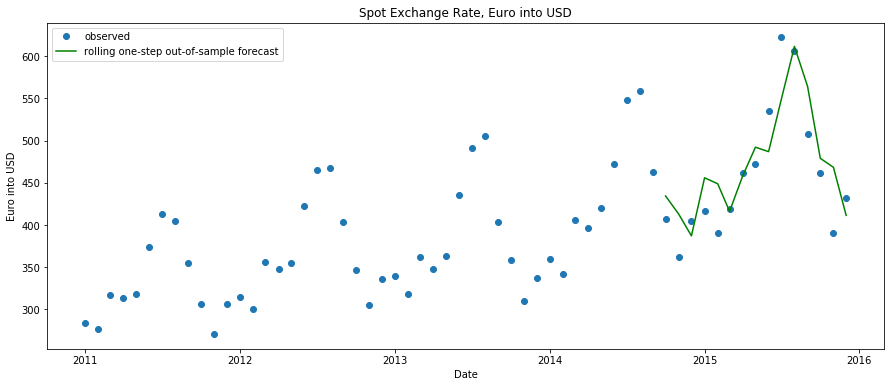

In [49]:
fig, ax = plt.subplots()
ax.set(title='Spot Exchange Rate, Euro into USD', xlabel='Date', ylabel='Euro into USD')
ax.plot(ts[-60:], 'o', label='observed')
ax.plot(np.exp(predictions_series), 'g', label='rolling one-step out-of-sample forecast')
legend = ax.legend(loc='upper left')
legend.get_frame().set_facecolor('w')

## 10.  FUTURE PREDICTION

#### We can do future prediction
###### plot_predict

In [50]:
ts_week_log.tail()
#To see last year in daatset

Month
2015-08-01    6.406880
2015-09-01    6.230481
2015-10-01    6.133398
2015-11-01    5.966147
2015-12-01    6.068426
Name: #Passengers, dtype: float64

In [51]:
ts_week_log.shape
#total 2237 records in data, we need to predict for another 10 year so steps = 12*10=120

(144,)

## 10.1 Graphically future  10 year Prediction

C:\Users\prabh\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:531: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:531: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:531: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  ValueWarning)


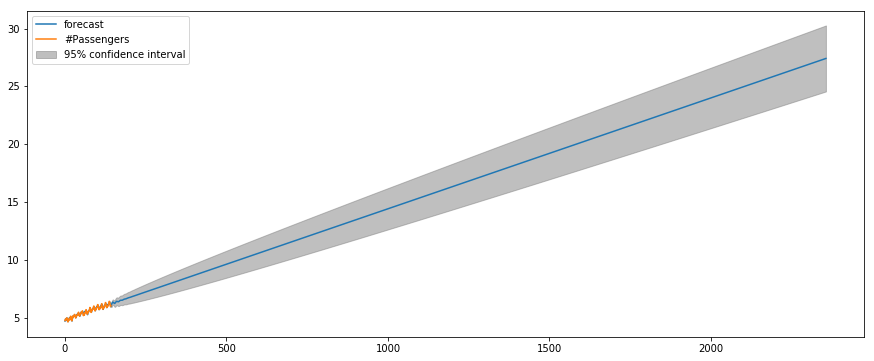

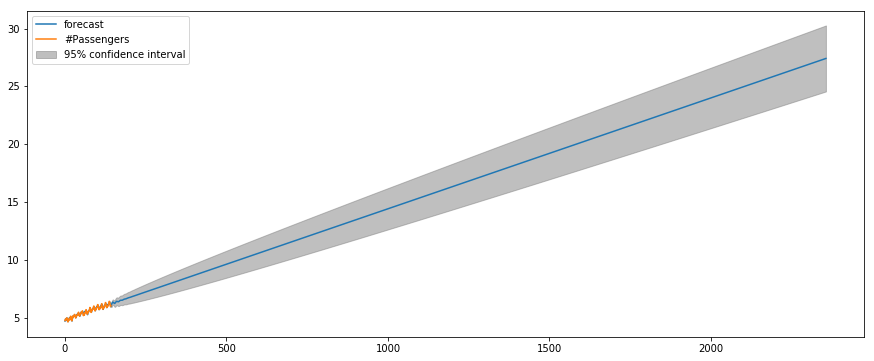

In [52]:
#2237 +120 = 2357
#Not clear on steps

#Graphically future of 10 year
results_ARIMA.plot_predict(1,2357)  # 2237

#Blue line is predicted after 2017

In [53]:
#Array wise future of 10 year
x = results_ARIMA.forecast(steps=120) #10 year prediction
x

(array([6.0955341 , 6.15281431, 6.22442995, 6.29241123, 6.34164724,
        6.36359353, 6.35784664, 6.33139277, 6.29597514, 6.26447697,
        6.24738322, 6.2502518 , 6.27275854, 6.30940333, 6.3515151 ,
        6.38988664, 6.41727379, 6.43011041, 6.4290667 , 6.41842468,
        6.40456138, 6.39403606, 6.39183082, 6.40019511, 6.41833705,
        6.4429542 , 6.46937445, 6.49293988, 6.51024114, 6.51989022,
        6.52267564, 6.52112373, 6.51864516, 6.51853684, 6.52311923,
        6.53322366, 6.54812877, 6.56591565, 6.58410313, 6.60036539,
        6.61313261, 6.62192772, 6.62737778, 6.63093119, 6.63438682,
        6.63937981, 6.64696505, 6.65739844, 6.67015329, 6.68414254,
        6.69806627, 6.71077899, 6.72157727, 6.73033976, 6.73749803,
        6.74386371, 6.75037318, 6.7578259 , 6.76668682, 6.77699824,
        6.78841321, 6.80032854, 6.81207193, 6.82308757, 6.83307131,
        6.84202487, 6.85022306, 6.85811216, 6.86617336, 6.87479149,
        6.88416302, 6.89426384, 6.90487889, 6.91